In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import splu, spsolve
from numpy.linalg import svd, norm, solve

# Esercizio 1 

In [2]:
def laplacian_1d(n_interior, dx):
    """Laplaciano 1D sui soli nodi interni, con Dirichlet omogenee."""
    main = -2.0 * np.ones(n_interior)
    off = np.ones(n_interior - 1)
    return diags([off, main, off], [-1, 0, 1], format='csc') / dx**2


def heat_1d(alpha, y0_fun, T=1.0, Nx=101, dt=1e-3, scheme='implicit', snapshot_stride=1):

    x = np.linspace(0.0, 1.0, Nx)
    dx = x[1] - x[0]
    n = Nx - 2
    L = laplacian_1d(n, dx)

    # adattiamo dt per arrivare esattamente a T
    Nt = int(np.ceil(T / dt))
    dt = T / Nt

    y = np.asarray(y0_fun(x[1:-1]), dtype=float)

    if scheme == 'explicit':
        r = alpha * dt / dx**2
        if r > 0.5 + 1e-14:
            raise ValueError(
                f"Schema esplicito instabile: alpha*dt/dx^2 = {r:.3f} > 0.5"
            )
        step = lambda yy: yy + dt * alpha * (L @ yy)

    elif scheme == 'implicit':
        # Metodo implicito (Backward Euler):
        # (I - dt * alpha * L) y^{k+1} = y^k
        M = (eye(n, format='csc') - dt * alpha * L).tocsc()

        # Fattorizzazione LU della matrice, calcolata una sola volta
        # perché M rimane costante a ogni passo temporale.
        lu = splu(M)

        # A ogni iterazione risolviamo il sistema lineare
        # per ottenere la soluzione al tempo successivo.
        step = lambda yy: lu.solve(yy)

    else:
        raise ValueError("scheme deve essere 'explicit' oppure 'implicit'")

    snapshots = []
    times = []

    def save(k, yy):
        full = np.zeros(Nx)
        full[1:-1] = yy
        snapshots.append(full)
        times.append(k * dt)

    save(0, y)
    for k in range(1, Nt + 1):
        y = step(y)
        if (k % snapshot_stride == 0) or (k == Nt):
            save(k, y)

    return x, np.asarray(times), np.column_stack(snapshots), dt


def y0_sine(x):
    return np.sin(np.pi * x)


def y0_pulse(x):
    # Nel dominio [0,1], sgn(x) è positiva nell'intervallo [0.3,0.7],
    # quindi la traccia coincide praticamente con un impulso rettangolare.
    return ((x >= 0.3) & (x <= 0.7)).astype(float)

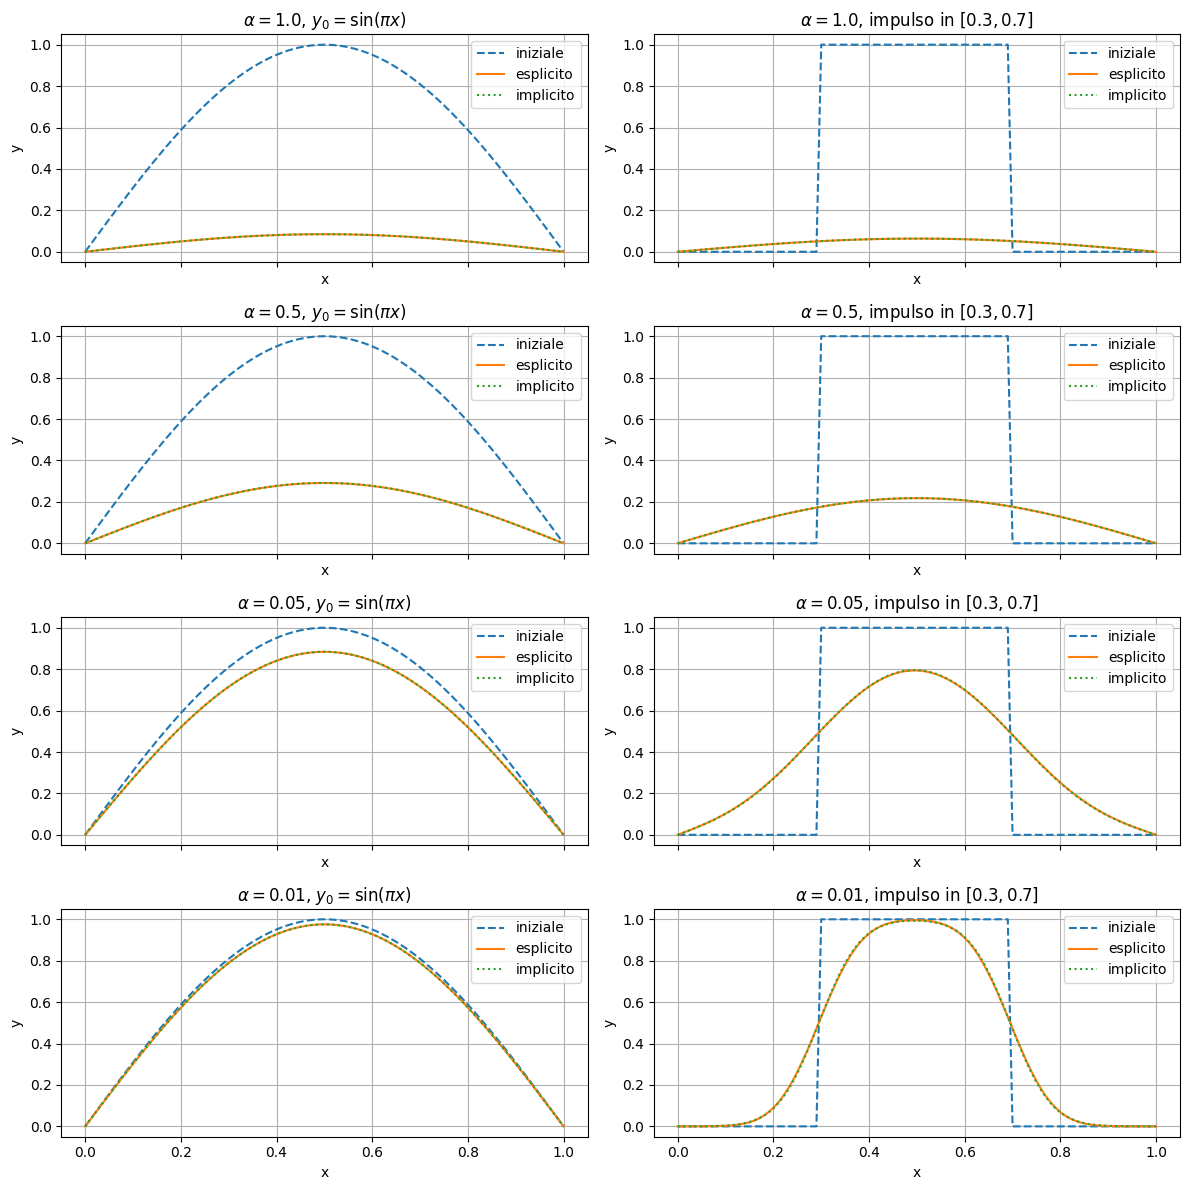

In [3]:
# Test delle configurazioni richieste
alphas = [1.0, 0.5, 0.05, 0.01]
Nx = 101
T = 0.25
x = np.linspace(0, 1, Nx)
dx = x[1] - x[0]

fig, axes = plt.subplots(len(alphas), 2, figsize=(12, 12), sharex=True)

for i, alpha in enumerate(alphas):
    # dt stabile per l'esplicito: scegliamo r = 0.45
    dt_exp = 0.45 * dx**2 / alpha  #per stabilita
    _, _, Y_exp_sin, _ = heat_1d(alpha, y0_sine, T=T, Nx=Nx, dt=dt_exp, scheme='explicit')
    _, _, Y_imp_sin, _ = heat_1d(alpha, y0_sine, T=T, Nx=Nx, dt=5*dt_exp, scheme='implicit')

    axes[i, 0].plot(x, Y_exp_sin[:, 0], '--', label='iniziale')
    axes[i, 0].plot(x, Y_exp_sin[:, -1], label='esplicito')
    axes[i, 0].plot(x, Y_imp_sin[:, -1], ':', label='implicito')
    axes[i, 0].set_title(fr'$\alpha={alpha}$, $y_0=\sin(\pi x)$')
    axes[i, 0].grid(True)

    _, _, Y_exp_p, _ = heat_1d(alpha, y0_pulse, T=T, Nx=Nx, dt=dt_exp, scheme='explicit')
    _, _, Y_imp_p, _ = heat_1d(alpha, y0_pulse, T=T, Nx=Nx, dt=5*dt_exp, scheme='implicit')

    axes[i, 1].plot(x, Y_exp_p[:, 0], '--', label='iniziale')
    axes[i, 1].plot(x, Y_exp_p[:, -1], label='esplicito')
    axes[i, 1].plot(x, Y_imp_p[:, -1], ':', label='implicito')
    axes[i, 1].set_title(fr'$\alpha={alpha}$, impulso in $[0.3,0.7]$')
    axes[i, 1].grid(True)

for ax in axes.ravel():
    ax.legend()
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

    schema     Nx           dx           dt      errore L2
  explicit     21   5.0000e-02   9.8039e-03     5.9798e-04
  implicit     21   5.0000e-02   9.8039e-03     1.4475e-03
  explicit     41   2.5000e-02   2.4631e-03     1.5213e-04
  implicit     41   2.5000e-02   2.4631e-03     3.6917e-04
  explicit     81   1.2500e-02   6.1652e-04     3.8317e-05
  implicit     81   1.2500e-02   6.1652e-04     9.3047e-05
  explicit    161   6.2500e-03   1.5418e-04     9.6122e-06
  implicit    161   6.2500e-03   1.5418e-04     2.3345e-05


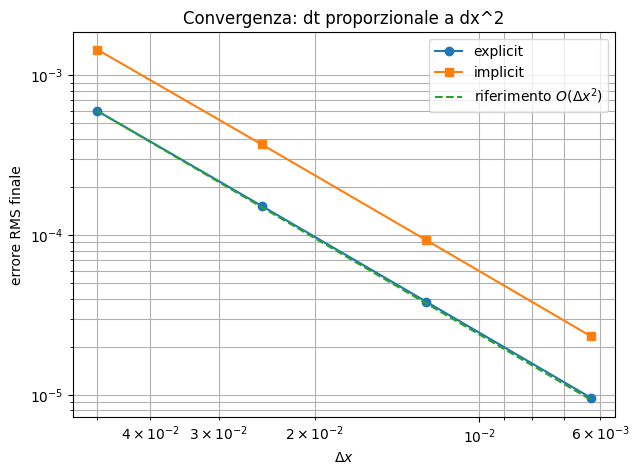

In [4]:
# ERRORE


def exact_heat(x, t):
    return np.exp(-t) * np.sin(np.pi * x)

alpha = 1 / np.pi**2
T = 0.5
Nx_list = [21, 41, 81, 161]
rows = []

for Nx in Nx_list:
    x = np.linspace(0, 1, Nx)
    dx = x[1] - x[0]

    # rapporto dt/dx^2 costante, così anche l'esplicito rimane stabile
    dt = 0.4 * dx**2 / alpha

    for scheme in ['explicit', 'implicit']:
        xh, th, Yh, dt_eff = heat_1d(alpha, y0_sine, T=T, Nx=Nx, dt=dt, scheme=scheme)
        err = norm(Yh[:, -1] - exact_heat(xh, T)) / np.sqrt(Nx)
        rows.append((scheme, Nx, dx, dt_eff, err))

print(f"{'schema':>10} {'Nx':>6} {'dx':>12} {'dt':>12} {'errore L2':>14}")
for r in rows:
    print(f"{r[0]:>10} {r[1]:6d} {r[2]:12.4e} {r[3]:12.4e} {r[4]:14.4e}")

plt.figure(figsize=(7,5))
for scheme, marker in [('explicit', 'o'), ('implicit', 's')]:
    rr = [r for r in rows if r[0] == scheme]
    dxs = np.array([r[2] for r in rr])
    errs = np.array([r[4] for r in rr])
    plt.loglog(dxs, errs, marker=marker, label=scheme)

ref = rows[0][4] * (np.array([r[2] for r in rows if r[0]=='explicit']) / rows[0][2])**2
plt.loglog(np.array([r[2] for r in rows if r[0]=='explicit']), ref, '--', label=r'riferimento $O(\Delta x^2)$')
plt.gca().invert_xaxis()
plt.xlabel(r'$\Delta x$')
plt.ylabel('errore RMS finale')
plt.title('Convergenza: dt proporzionale a dx^2')
plt.grid(True, which='both')
plt.legend()
plt.show()

# Esercizio 2

In [5]:
def pod_basis(Y, r=None):  #primi r vettori singolari sinistri
    U, s, VT = svd(Y, full_matrices=False)
    if r is None:
        r = U.shape[1]
    return U[:, :r], s, VT


def pod_projection_error(Y, U, l):
    Phi = U[:, :l]
    return norm(Y - Phi @ (Phi.T @ Y), 'fro') / norm(Y, 'fro')  
    #Y-(PP^T)Y ovvero riproiettato in norma di Frobenius


def heat_1d_rom(alpha, Phi, y0_full, T, dt): #Backward Euler sul Reduced Order Model (ROM)
    
    Nx = len(y0_full) 
    dx = 1.0 / (Nx - 1) 
    Nt = int(np.ceil(T / dt)) 
    dt = T / Nt 


    # Costruzione dell'operatore di Laplace sulla griglia completa.
    Lint = laplacian_1d(Nx - 2, dx) 
    L_full = sparse.lil_matrix((Nx, Nx)) 
    L_full[1:-1, 1:-1] = Lint 
    L_full = L_full.tocsc() 

    # Proiezione dell'operatore completo nello spazio ridotto POD.
    Al = alpha * (Phi.T @ (L_full @ Phi))   # Al = (l x l)

    # Proiezione della condizione iniziale nella base POD.
    y0_l = Phi.T @ y0_full 

    # Matrice di Backward Euler per il sistema ridotto:
    # (I - dt*Al) z^{k+1} = z^k
    Ml = np.eye(Phi.shape[1]) - dt * Al 

    # Matrice che conterrà la soluzione ROM ricostruita
    # nello spazio originale.
    Yrom = np.empty((Nx, Nt + 1)) 
    Yrom[:, 0] = Phi @ y0_l 

    for k in range(Nt): 
        # Evoluzione nel sistema ridotto
        y0_l = solve(Ml, y0_l) 

        # Ricostruzione della soluzione nello spazio completo
        Yrom[:, k+1] = Phi @ y0_l 

    return Yrom, dt

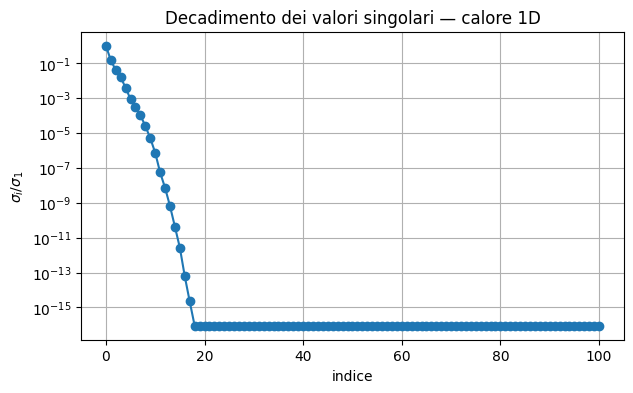

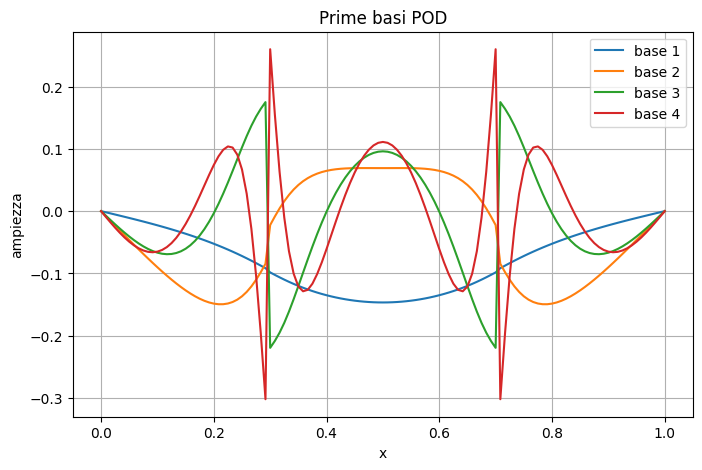

In [6]:
# Caso singolo: alpha = 0.05
alpha = 0.05
Nx = 121
T = 1.0
x = np.linspace(0, 1, Nx)
dx = x[1] - x[0]
dt = 0.002

# Calcoliamo la soluzione FOM su griglia temporale fitta,
# ma salviamo gli snapshots solo ogni 5 passi per costruire la POD.
start = time.perf_counter()
x, ts, Ysnap, dt_eff = heat_1d(alpha, y0_pulse, T=T, Nx=Nx, dt=dt,
                               scheme='implicit', snapshot_stride=5)
time_fom_snap = time.perf_counter() - start

U, s, VT = pod_basis(Ysnap)

plt.figure(figsize=(7,4))
plt.semilogy(s / s[0], 'o-')
plt.xlabel('indice')
plt.ylabel(r'$\sigma_i/\sigma_1$')
plt.title('Decadimento dei valori singolari — calore 1D')
plt.grid(True)
plt.show()

# Prime 4 basi POD
plt.figure(figsize=(8,5))
for j in range(min(4, U.shape[1])):
    plt.plot(x, U[:, j], label=f'base {j+1}')
plt.xlabel('x')
plt.ylabel('ampiezza')
plt.title('Prime basi POD')
plt.grid(True)
plt.legend()
plt.show()

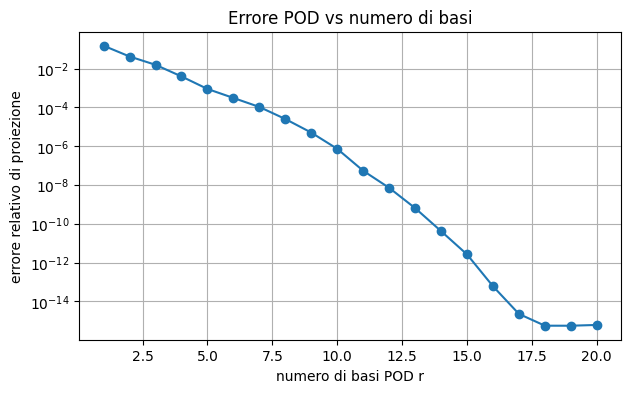

In [7]:
# Errore POD in funzione del numero di basi
r_values = list(range(1, min(21, U.shape[1]+1)))
proj_errors = [pod_projection_error(Ysnap, U, r) for r in r_values]

plt.figure(figsize=(7,4))
plt.semilogy(r_values, proj_errors, 'o-')
plt.xlabel('numero di basi POD r')
plt.ylabel('errore relativo di proiezione')
plt.title('Errore POD vs numero di basi')
plt.grid(True)
plt.show()

r = 8
Errore ROM relativo: 1.1844e-03
Tempo FOM: 0.0088 s
Tempo ROM: 0.0189 s
Speed-up indicativo: 0.46x


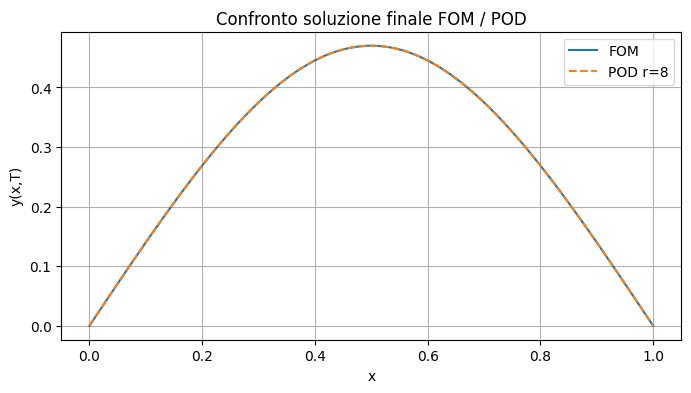

In [7]:
# Confronto FOM vs ROM sulla griglia temporale fitta
r = min(8, U.shape[1])
Phi = U[:, :r]
y0_full = np.zeros(Nx)
y0_full[1:-1] = y0_pulse(x[1:-1])

start = time.perf_counter()
_, _, Yfom_fine, dt_fine = heat_1d(alpha, y0_pulse, T=T, Nx=Nx, dt=dt,
                                    scheme='implicit', snapshot_stride=1)
time_fom = time.perf_counter() - start

start = time.perf_counter()
Yrom, _ = heat_1d_rom(alpha, Phi, y0_full, T=T, dt=dt)
time_rom = time.perf_counter() - start

rom_err = norm(Yfom_fine - Yrom, 'fro') / norm(Yfom_fine, 'fro')

print(f'r = {r}')
print(f'Errore ROM relativo: {rom_err:.4e}')
print(f'Tempo FOM: {time_fom:.4f} s')
print(f'Tempo ROM: {time_rom:.4f} s')
print(f'Speed-up indicativo: {time_fom / max(time_rom,1e-15):.2f}x')

plt.figure(figsize=(8,4))
plt.plot(x, Yfom_fine[:, -1], label='FOM')
plt.plot(x, Yrom[:, -1], '--', label=f'POD r={r}')
plt.xlabel('x')
plt.ylabel('y(x,T)')
plt.title('Confronto soluzione finale FOM / POD')
plt.grid(True)
plt.legend()
plt.show()

## POD parametrica

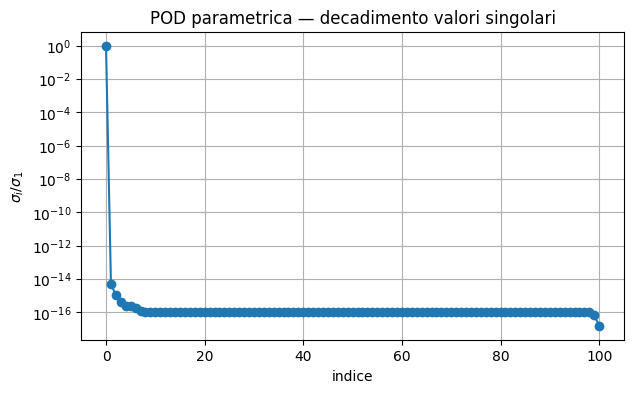

Parametro test alpha=0.373: errore POD relativo = 7.4812e-15


In [8]:
alpha_train = np.linspace(0.01, 1.0, 8)
Nx = 101
T = 0.5
dt = 0.002
banks = []

for a in alpha_train:
    _, _, Ya, _ = heat_1d(a, y0_sine, T=T, Nx=Nx, dt=dt,
                           scheme='implicit', snapshot_stride=10)
    banks.append(Ya)

Ypar = np.hstack(banks)
Upar, spar, _ = pod_basis(Ypar)

plt.figure(figsize=(7,4))
plt.semilogy(spar / spar[0], 'o-')
plt.xlabel('indice')
plt.ylabel(r'$\sigma_i/\sigma_1$')
plt.title('POD parametrica — decadimento valori singolari')
plt.grid(True)
plt.show()

# Test su parametro non usato nel training
alpha_test = 0.373
r = min(6, Upar.shape[1])
Phi = Upar[:, :r]
x = np.linspace(0, 1, Nx)
y0_full = np.sin(np.pi * x)
y0_full[[0,-1]] = 0

_, _, Ytest, _ = heat_1d(alpha_test, y0_sine, T=T, Nx=Nx, dt=dt,
                          scheme='implicit', snapshot_stride=1)
Yrom, _ = heat_1d_rom(alpha_test, Phi, y0_full, T=T, dt=dt)
err = norm(Ytest - Yrom, 'fro') / norm(Ytest, 'fro')
print(f'Parametro test alpha={alpha_test}: errore POD relativo = {err:.4e}')

# Esercizio 3 

In [9]:
def laplacian_2d(n, h):
    """Laplaciano 2D su griglia interna n x n, Dirichlet omogenee."""

    # Costruiamo il Laplaciano 1D:
    # discretizza la derivata seconda lungo una sola direzione spaziale.
    L1 = laplacian_1d(n, h)

    # Matrice identità di dimensione n.
    I = eye(n, format='csc')

 # In 2D il Laplaciano è:
    #
    #     Δu = u_xx + u_yy
    #
    # quindi dobbiamo sommare la derivata seconda lungo x
    # e la derivata seconda lungo y.
    #
    # Il simbolo ⊗ indica il prodotto di Kronecker.
    #
    # Per esempio, se:
    #
    #     I = [1 0]      L1 = [-2  1]
    #         [0 1]           [ 1 -2]
    #
    # allora:
    #
    #     I ⊗ L1 =
    #
    #     [-2  1  0  0]
    #     [ 1 -2  0  0]
    #     [ 0  0 -2  1]
    #     [ 0  0  1 -2]
    #
    # cioè vengono messe due copie di L1 sulla diagonale.
    # Questo rappresenta la derivata seconda lungo una direzione.
    #
    # Invece:
    #
    #     L1 ⊗ I =
    #
    #     [-2  0  1  0]
    #     [ 0 -2  0  1]
    #     [ 1  0 -2  0]
    #     [ 0  1  0 -2]
    #
    # rappresenta la derivata seconda lungo l'altra direzione.
    #
    # Sommando i due contributi:
    #
    #     L_2D = I ⊗ L1 + L1 ⊗ I
    #
    # otteniamo:
    #
    #     [-4  1  1  0]
    #     [ 1 -4  0  1]
    #     [ 1  0 -4  1]
    #     [ 0  1  1 -4]
    #
    # Il -4 sulla diagonale deriva da:
    #
    #     -2 dalla direzione x
    #     -2 dalla direzione y
    #
    # quindi:
    #
    #     -2 - 2 = -4
    #
    # Gli 1 rappresentano invece i punti vicini.
    #
    # In questo modo si ottiene il classico stencil a 5 punti
    # per il Laplaciano 2D.

    
    return kron(I, L1, format='csc') + kron(L1, I, format='csc')

In [10]:
def heat_2d_implicit(alpha, y0_fun, T=1.0, N=31, dt=0.01, snapshot_stride=1):

    # Griglia spaziale.
    x = np.linspace(0, 1, N)
    h = x[1] - x[0]

    # Consideriamo solo i nodi interni.
    xi = x[1:-1]
    X, Y = np.meshgrid(xi, xi, indexing='ij')

    n = N - 2

    # Operatore di Laplace 2D.
    L = laplacian_2d(n, h)

    # Condizione iniziale vettorializzata.
    y = np.asarray(y0_fun(X, Y), dtype=float).reshape(-1)

    # Numero di passi temporali.
    Nt = int(np.ceil(T / dt))
    dt = T / Nt

    # Matrice di Backward Euler:
    # (I - dt*alpha*L) y^{k+1} = y^k
    M = eye(n*n, format='csc') - dt * alpha * L

    # Fattorizzazione LU calcolata una sola volta.
    lu = splu(M)

    # Salvataggio degli snapshots.
    snaps = [y.copy()]
    times = [0.0]

    for k in range(1, Nt+1):
        # Evoluzione temporale con schema implicito.
        y = lu.solve(y)

        # Salviamo solo alcuni istanti temporali.
        if (k % snapshot_stride == 0) or (k == Nt):
            snaps.append(y.copy())
            times.append(k*dt)

    return x, X, Y, np.array(times), np.column_stack(snaps), L, dt


def y0_2d_smooth(X, Y):
    # Condizione iniziale regolare.
    return np.sin(2*np.pi*X) * np.sin(2*np.pi*Y)


def y0_2d_square(X, Y):
    # Condizione iniziale uguale a 1 nel quadrato centrale e 0 altrove.
    return ((X > 0.25) & (X < 0.75) &
            (Y > 0.25) & (Y < 0.75)).astype(float)


def plot_2d_snapshot(x, vec, title=''):
    # Ricostruiamo la soluzione 2D aggiungendo i bordi nulli.
    N = len(x)
    n = N - 2

    Z = np.zeros((N, N))
    Z[1:-1, 1:-1] = vec.reshape(n, n)

    # Visualizzazione della soluzione.
    plt.figure(figsize=(5,4))
    plt.imshow(Z.T, origin='lower',
               extent=[0,1,0,1], aspect='equal')

    plt.colorbar(label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.show()

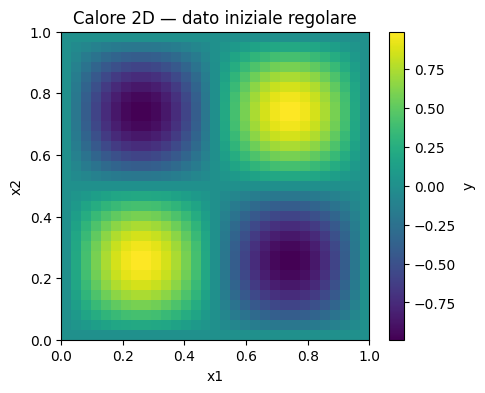

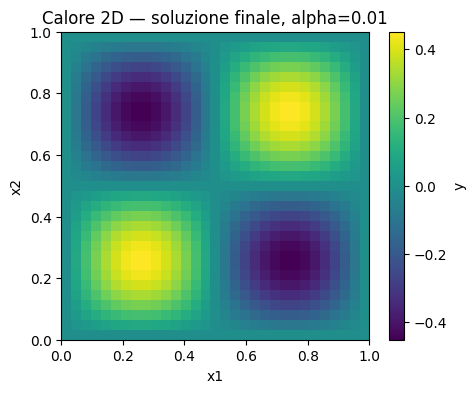

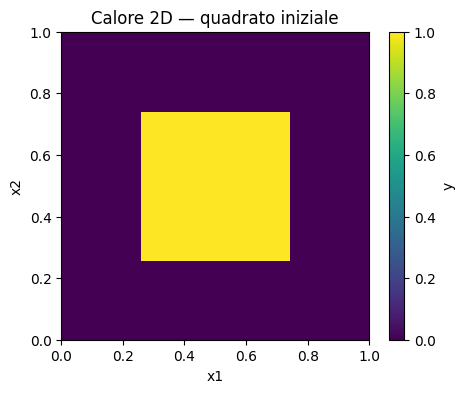

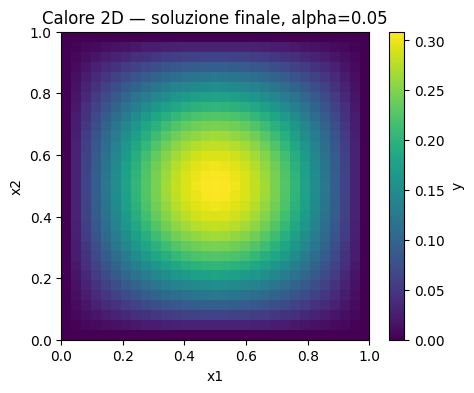

In [11]:
# Configurazione 1: alpha=0.01, dato iniziale regolare
x, X, Y, ts, Y2d_smooth, L2d, dt2d = heat_2d_implicit(
    alpha=0.01, y0_fun=y0_2d_smooth, T=1.0, N=31, dt=0.01, snapshot_stride=2
)
plot_2d_snapshot(x, Y2d_smooth[:, 0], 'Calore 2D — dato iniziale regolare')
plot_2d_snapshot(x, Y2d_smooth[:, -1], 'Calore 2D — soluzione finale, alpha=0.01')

# Configurazione 2: alpha=0.05, dato iniziale discontinuo
x2, X2, Y2, ts2, Y2d_square, L2d_2, dt2 = heat_2d_implicit(
    alpha=0.05, y0_fun=y0_2d_square, T=1.0, N=31, dt=0.01, snapshot_stride=2
)
plot_2d_snapshot(x2, Y2d_square[:, 0], 'Calore 2D — quadrato iniziale')
plot_2d_snapshot(x2, Y2d_square[:, -1], 'Calore 2D — soluzione finale, alpha=0.05')

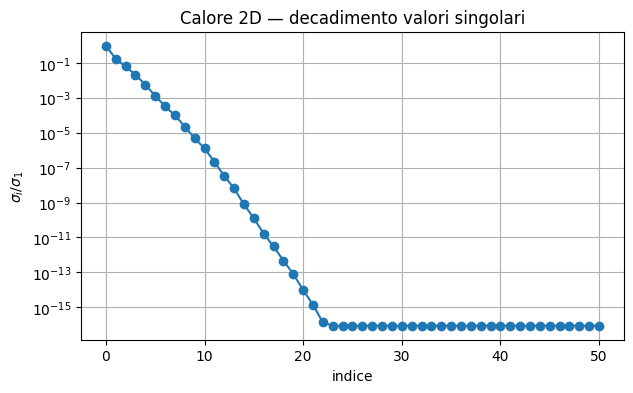

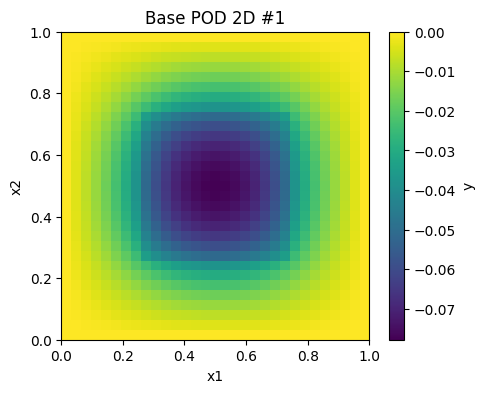

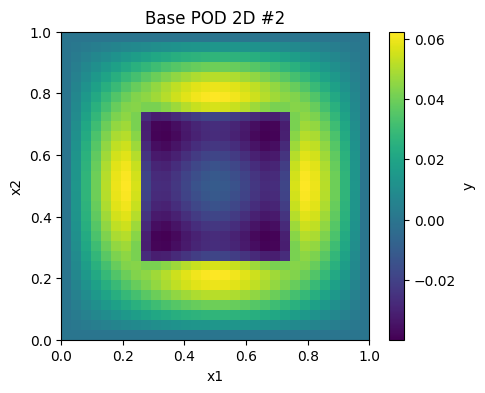

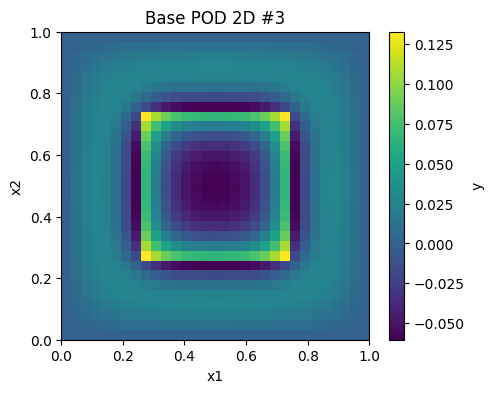

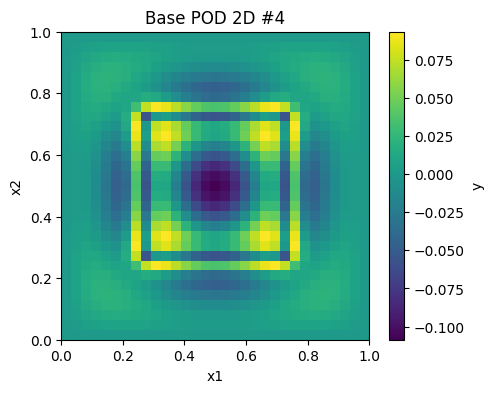

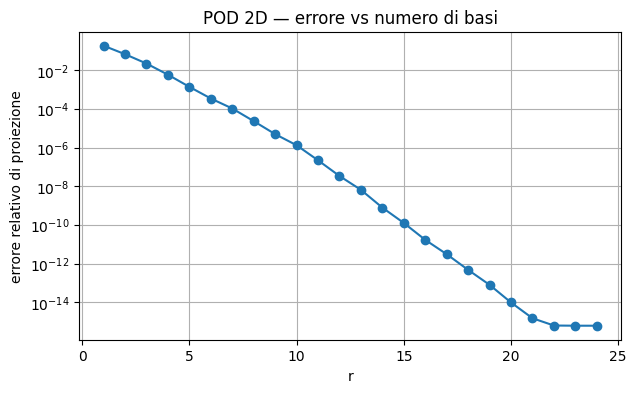

In [12]:
# POD sul caso 2D discontinuo
U2, s2, _ = pod_basis(Y2d_square)

plt.figure(figsize=(7,4))
plt.semilogy(s2/s2[0], 'o-')
plt.xlabel('indice')
plt.ylabel(r'$\sigma_i/\sigma_1$')
plt.title('Calore 2D — decadimento valori singolari')
plt.grid(True)
plt.show()

for j in range(min(4, U2.shape[1])):
    plot_2d_snapshot(x2, U2[:, j], f'Base POD 2D #{j+1}')

rvals = range(1, min(25, U2.shape[1]+1))
errs2 = [pod_projection_error(Y2d_square, U2, r) for r in rvals]
plt.figure(figsize=(7,4))
plt.semilogy(list(rvals), errs2, 'o-')
plt.xlabel('r')
plt.ylabel('errore relativo di proiezione')
plt.title('POD 2D — errore vs numero di basi')
plt.grid(True)
plt.show()

In [13]:
def heat_2d_rom(alpha, Phi, L, y0, T, dt):
    Ar = alpha * (Phi.T @ (L @ Phi))
    z = Phi.T @ y0
    Nt = int(np.ceil(T/dt))
    dt = T/Nt
    Mr = np.eye(Phi.shape[1]) - dt * Ar

    Yrom = np.empty((Phi.shape[0], Nt+1))
    Yrom[:,0] = Phi @ z
    for k in range(Nt):
        z = solve(Mr, z)
        Yrom[:,k+1] = Phi @ z
    return Yrom

# Confronto tempi sul caso alpha=0.05
N = 31
x = np.linspace(0,1,N)
xi = x[1:-1]
XX, YY = np.meshgrid(xi, xi, indexing='ij')
y0 = y0_2d_square(XX,YY).reshape(-1)
alpha = 0.05
T = 1.0
dt = 0.01
r = min(12, U2.shape[1])
Phi2 = U2[:,:r]

start = time.perf_counter()
_, _, _, _, Yfom2, L2, _ = heat_2d_implicit(alpha, y0_2d_square, T=T, N=N, dt=dt, snapshot_stride=1)
tfom = time.perf_counter()-start

start = time.perf_counter()
Yrom2 = heat_2d_rom(alpha, Phi2, L2, y0, T=T, dt=dt)
trom = time.perf_counter()-start

err2 = norm(Yfom2-Yrom2,'fro')/norm(Yfom2,'fro')
print(f'POD 2D r={r}, errore={err2:.4e}')
print(f'Tempo FOM={tfom:.4f}s, ROM={trom:.4f}s, speed-up={tfom/max(trom,1e-15):.2f}x')

POD 2D r=12, errore=4.6477e-06
Tempo FOM=0.0142s, ROM=0.0026s, speed-up=5.51x


### Caso parametrico 2D
La stessa procedura si applica concatenando snapshots per più valori di \(\alpha\). La cella seguente crea una POD parametrica e la testa su un valore non presente nel training.

In [14]:
alpha_train_2d = [0.01, 0.03, 0.07, 0.15]
bank2d = []
N = 25
for a in alpha_train_2d:
    _, _, _, _, Ya, _, _ = heat_2d_implicit(a, y0_2d_smooth, T=0.5, N=N, dt=0.01, snapshot_stride=5)
    bank2d.append(Ya)

Ypar2d = np.hstack(bank2d)
Upar2d, spar2d, _ = pod_basis(Ypar2d)
alpha_test_2d = 0.055
r = min(8, Upar2d.shape[1])
Phi = Upar2d[:, :r]

x = np.linspace(0,1,N)
xi = x[1:-1]
XX, YY = np.meshgrid(xi,xi,indexing='ij')
y0 = y0_2d_smooth(XX,YY).reshape(-1)

_,_,_,_,Ytest2d,Ltest,_ = heat_2d_implicit(alpha_test_2d, y0_2d_smooth, T=0.5, N=N, dt=0.01, snapshot_stride=1)
Yromtest2d = heat_2d_rom(alpha_test_2d, Phi, Ltest, y0, T=0.5, dt=0.01)
print('Errore POD parametrica 2D:', norm(Ytest2d-Yromtest2d,'fro')/norm(Ytest2d,'fro'))

Errore POD parametrica 2D: 2.0251730373975388e-15


# Esercizio 4 

In [15]:
def transport(c, y0_fun, T=1.0, Nx=301, dt=None, snapshot_stride=1):
    x = np.linspace(0,3,Nx)
    dx = x[1]-x[0]
    if dt is None:
        dt = 0.8*dx/c
    Nt = int(np.ceil(T/dt))
    dt = T/Nt
    CFL = c*dt/dx
    if CFL > 1+1e-14:
        raise ValueError(f'CFL={CFL:.3f} > 1')

    y = y0_fun(x).astype(float)
    y[0]=0; y[-1]=0
    snaps=[y.copy()]
    times=[0.0]

    for k in range(1,Nt+1):
        yn = y.copy()
        y[1:] = yn[1:] - CFL*(yn[1:]-yn[:-1])
        y[0]=0.0
        # La traccia impone anche y(b,t)=0.
        y[-1]=0.0
        if (k%snapshot_stride==0) or (k==Nt):
            snaps.append(y.copy()); times.append(k*dt)
    return x, np.array(times), np.column_stack(snaps), dt


def tr_y0_sine(x):
    return np.sin(np.pi*x) * ((x>=0)&(x<=1))


def tr_y0_pulse(x):
    return ((x>=0.3)&(x<=0.7)).astype(float)


def tr_exact(x,t,c,y0_fun):
    return y0_fun(x-c*t)

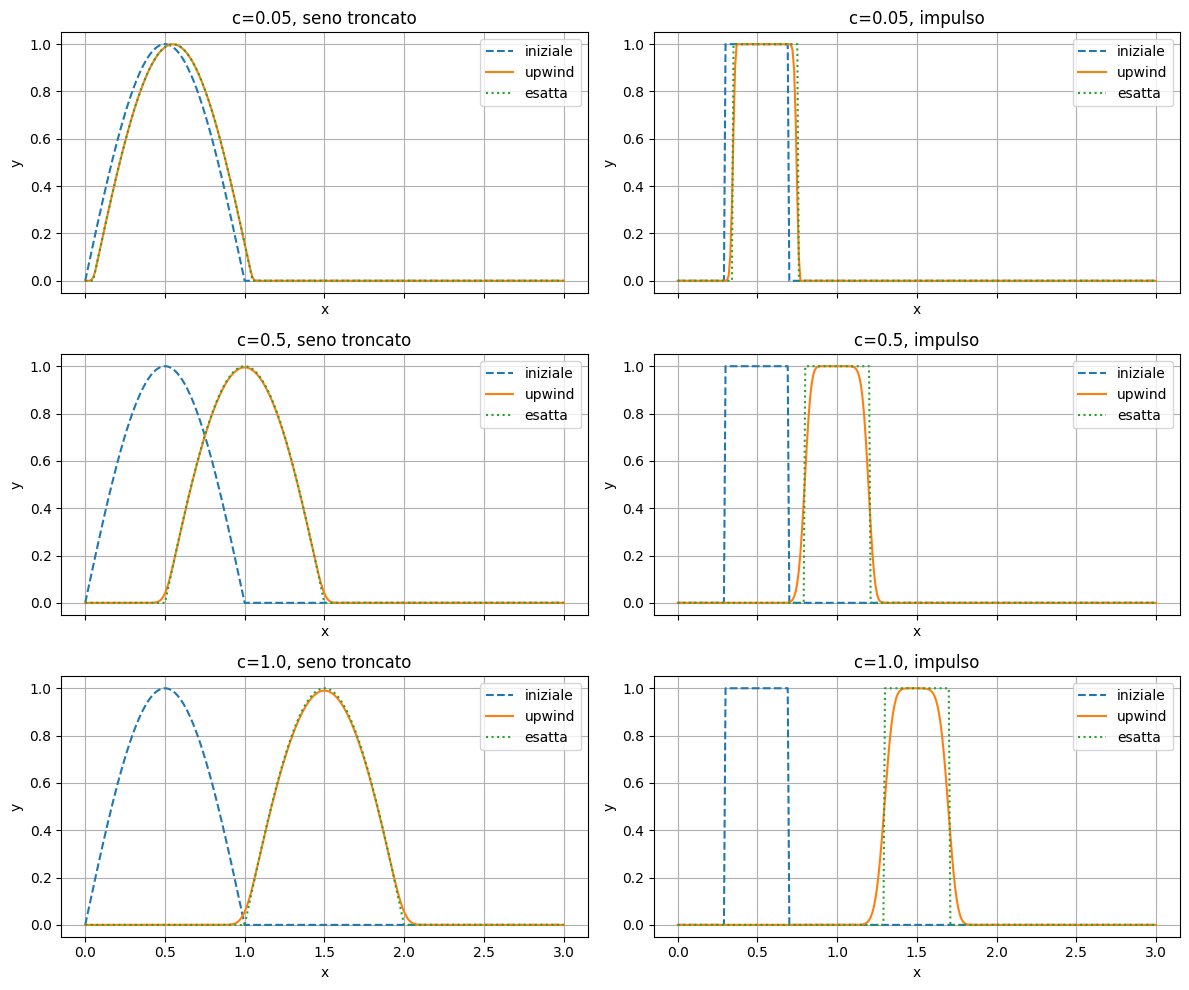

In [16]:
cs=[0.05,0.5,1.0]
fig,axes=plt.subplots(len(cs),2,figsize=(12,10),sharex=True)
for i,c in enumerate(cs):
    for j,(fun,name) in enumerate([(tr_y0_sine,'seno troncato'),(tr_y0_pulse,'impulso')]):
        x,ts,Ytr,dttr=transport(c,fun,T=1,Nx=301,snapshot_stride=5)
        axes[i,j].plot(x,Ytr[:,0],'--',label='iniziale')
        axes[i,j].plot(x,Ytr[:,-1],label='upwind')
        axes[i,j].plot(x,tr_exact(x,1,c,fun),':',label='esatta')
        axes[i,j].set_title(f'c={c}, {name}')
        axes[i,j].grid(True); axes[i,j].legend()
        axes[i,j].set_xlabel('x'); axes[i,j].set_ylabel('y')
plt.tight_layout(); plt.show()

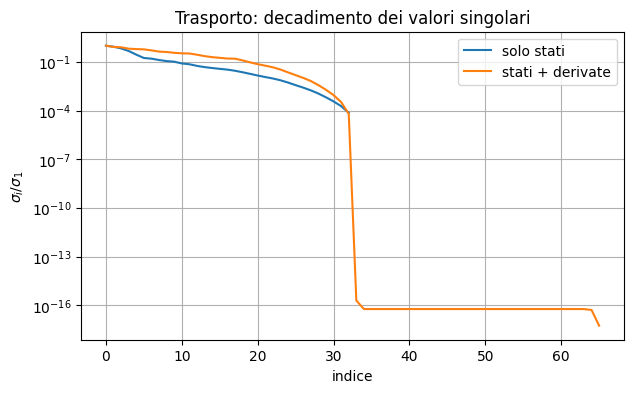

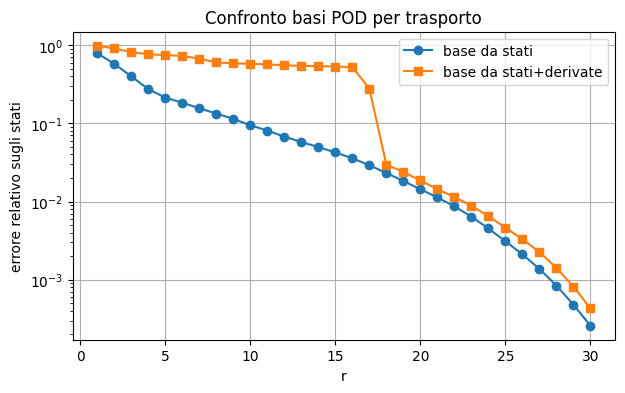

In [18]:
def time_derivative_snapshots(Y, times):
    """Derivata temporale numerica: gradient lungo la direzione tempo."""
    return np.gradient(Y, times, axis=1, edge_order=2)

c=1.0
x,ts,Ystate,_=transport(c,tr_y0_pulse,T=1,Nx=301,snapshot_stride=4)
Ydot=time_derivative_snapshots(Ystate,ts)

# Due matrici di training
Ya=Ystate
derivative_weight=1.0
Yb=np.hstack([Ystate, derivative_weight*Ydot])

Ua,sa,_=pod_basis(Ya)
Ub,sb,_=pod_basis(Yb)

plt.figure(figsize=(7,4))
plt.semilogy(sa/sa[0],label='solo stati')
plt.semilogy(sb/sb[0],label='stati + derivate')
plt.xlabel('indice'); plt.ylabel(r'$\sigma_i/\sigma_1$')
plt.title('Trasporto: decadimento dei valori singolari')
plt.grid(True); plt.legend(); plt.show()

rvals=range(1,31)
err_a=[pod_projection_error(Ystate,Ua,r) for r in rvals]
err_b=[pod_projection_error(Ystate,Ub,r) for r in rvals]

plt.figure(figsize=(7,4))
plt.semilogy(list(rvals),err_a,'o-',label='base da stati')
plt.semilogy(list(rvals),err_b,'s-',label='base da stati+derivate')
plt.xlabel('r'); plt.ylabel('errore relativo sugli stati')
plt.title('Confronto basi POD per trasporto')
plt.grid(True); plt.legend(); plt.show()

# Esercizio 5

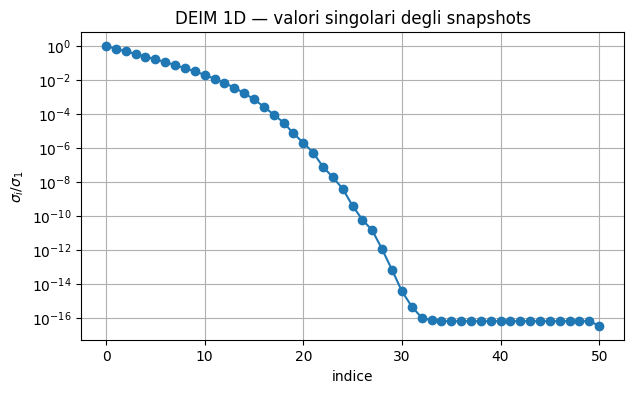

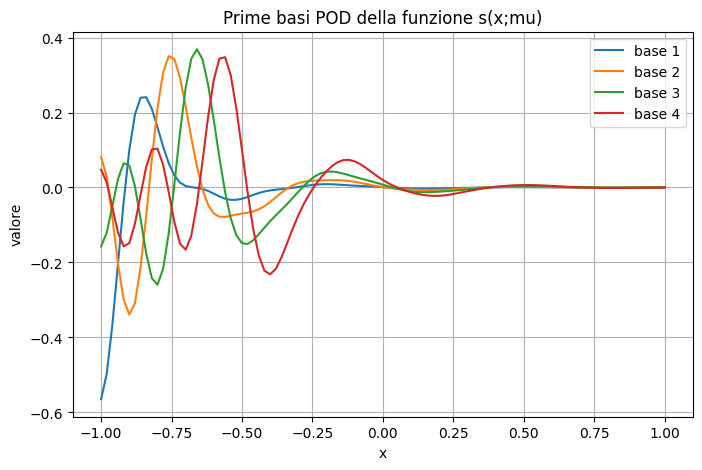

In [19]:
def deim_indices(U, m=None):
    if m is None:
        m = U.shape[1]
    U = U[:, :m]
    p = [int(np.argmax(np.abs(U[:,0])))]

    for j in range(1,m):
        Uprev = U[:, :j]
        rhs = U[p, j]
        coeff = solve(Uprev[p, :], rhs)
        residual = U[:,j] - Uprev @ coeff
        p.append(int(np.argmax(np.abs(residual))))
    return np.array(p, dtype=int)


def s1d(x, mu):
    return (1-x)*np.cos(3*np.pi*mu*(x+1))*np.exp(-(1+x)*mu)

x_deim=np.linspace(-1,1,101)
mu_train=np.linspace(1,np.pi,51)
S=np.column_stack([s1d(x_deim,mu) for mu in mu_train])
U5,s5,_=pod_basis(S)

plt.figure(figsize=(7,4))
plt.semilogy(s5/s5[0],'o-')
plt.xlabel('indice'); plt.ylabel(r'$\sigma_i/\sigma_1$')
plt.title('DEIM 1D — valori singolari degli snapshots')
plt.grid(True); plt.show()

plt.figure(figsize=(8,5))
for j in range(4):
    plt.plot(x_deim,U5[:,j],label=f'base {j+1}')
plt.xlabel('x'); plt.ylabel('valore')
plt.title('Prime basi POD della funzione s(x;mu)')
plt.grid(True); plt.legend(); plt.show()

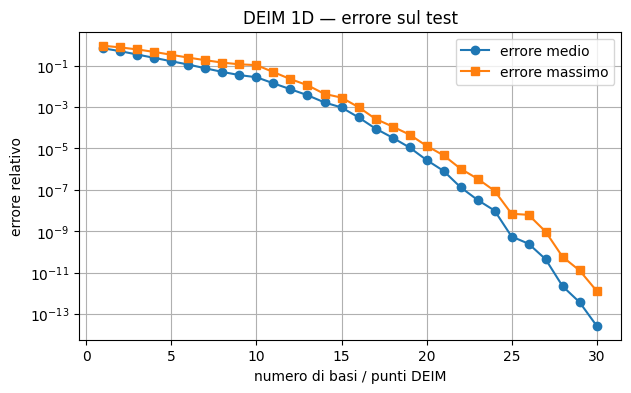

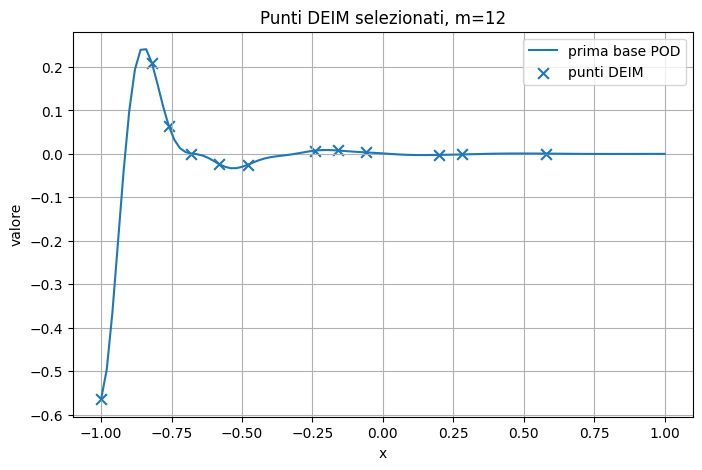

In [20]:
def deim_approx_1d(mu, U, p, x):
    Phi=U[:,:len(p)]
    fp=s1d(x[p],mu)
    coeff=solve(Phi[p,:],fp)
    return Phi@coeff

mu_test=np.linspace(1,np.pi,101)
m_values=range(1,min(31,U5.shape[1]+1))
mean_err=[]; max_err=[]

for m in m_values:
    p=deim_indices(U5,m)
    errs=[]
    for mu in mu_test:
        f=s1d(x_deim,mu)
        fa=deim_approx_1d(mu,U5,p,x_deim)
        errs.append(norm(f-fa)/norm(f))
    mean_err.append(np.mean(errs)); max_err.append(np.max(errs))

plt.figure(figsize=(7,4))
plt.semilogy(list(m_values),mean_err,'o-',label='errore medio')
plt.semilogy(list(m_values),max_err,'s-',label='errore massimo')
plt.xlabel('numero di basi / punti DEIM')
plt.ylabel('errore relativo')
plt.title('DEIM 1D — errore sul test')
plt.grid(True); plt.legend(); plt.show()

m=12
p=deim_indices(U5,m)
plt.figure(figsize=(8,5))
plt.plot(x_deim,U5[:,0],label='prima base POD')
plt.scatter(x_deim[p],U5[p,0],marker='x',s=60,label='punti DEIM')
plt.xlabel('x'); plt.ylabel('valore')
plt.title(f'Punti DEIM selezionati, m={m}')
plt.grid(True); plt.legend(); plt.show()

# Esercizio 6 

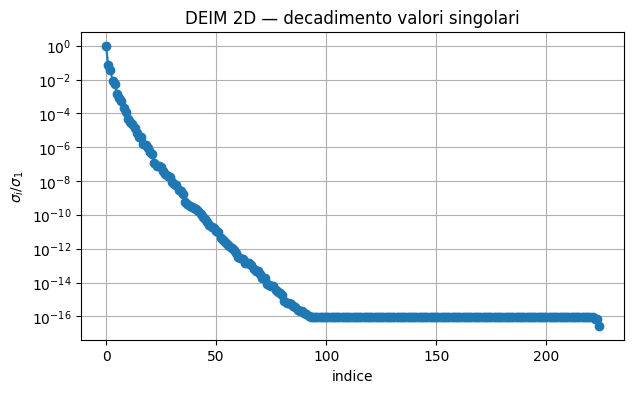

In [21]:
def s2d(x,y,mu1,mu2):
    return 1.0/np.sqrt((x-mu1)**2 + (y-mu2)**2 + 0.1**2)

nspace=20
xs=np.linspace(0.1,0.9,nspace)
ys=np.linspace(0.1,0.9,nspace)
XX,YY=np.meshgrid(xs,ys,indexing='ij')
xy=np.column_stack([XX.ravel(),YY.ravel()])

mus=np.linspace(-1,-0.01,15)
S2=[]
for mu1 in mus:
    for mu2 in mus:
        S2.append(s2d(xy[:,0],xy[:,1],mu1,mu2))
S2=np.column_stack(S2)
U6,s6,_=pod_basis(S2)

plt.figure(figsize=(7,4))
plt.semilogy(s6/s6[0],'o-')
plt.xlabel('indice'); plt.ylabel(r'$\sigma_i/\sigma_1$')
plt.title('DEIM 2D — decadimento valori singolari')
plt.grid(True); plt.show()

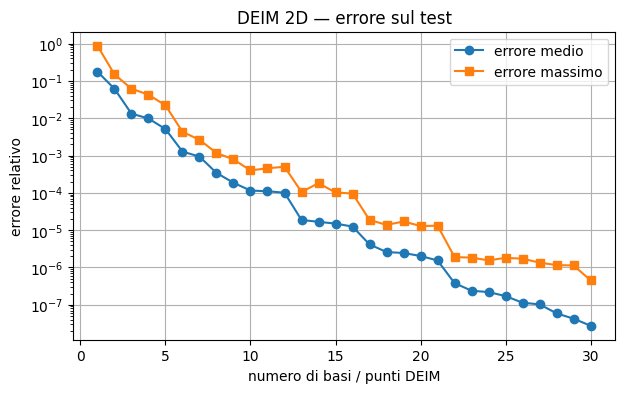

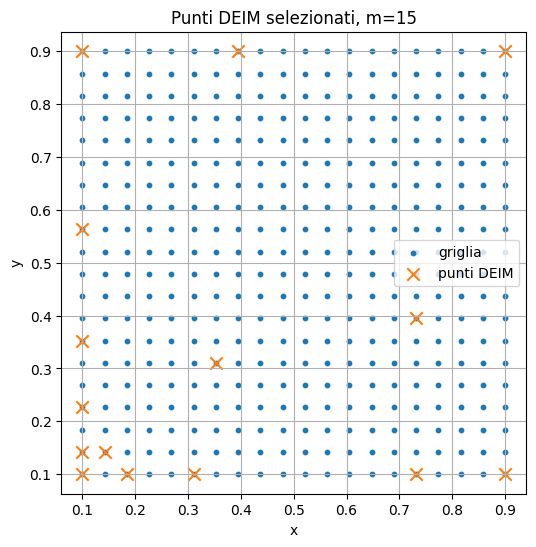

In [22]:
def deim_approx_2d(mu1,mu2,U,p,xy):
    Phi=U[:,:len(p)]
    fp=s2d(xy[p,0],xy[p,1],mu1,mu2)
    coeff=solve(Phi[p,:],fp)
    return Phi@coeff

mus_test=np.linspace(-1,-0.01,25)
m_values=range(1,min(31,U6.shape[1]+1))
mean_err2=[]; max_err2=[]

for m in m_values:
    p=deim_indices(U6,m)
    errs=[]
    for mu1 in mus_test:
        for mu2 in mus_test:
            f=s2d(xy[:,0],xy[:,1],mu1,mu2)
            fa=deim_approx_2d(mu1,mu2,U6,p,xy)
            errs.append(norm(f-fa)/norm(f))
    mean_err2.append(np.mean(errs)); max_err2.append(np.max(errs))

plt.figure(figsize=(7,4))
plt.semilogy(list(m_values),mean_err2,'o-',label='errore medio')
plt.semilogy(list(m_values),max_err2,'s-',label='errore massimo')
plt.xlabel('numero di basi / punti DEIM')
plt.ylabel('errore relativo')
plt.title('DEIM 2D — errore sul test')
plt.grid(True); plt.legend(); plt.show()

m=15
p=deim_indices(U6,m)
plt.figure(figsize=(6,6))
plt.scatter(xy[:,0],xy[:,1],s=10,label='griglia')
plt.scatter(xy[p,0],xy[p,1],marker='x',s=80,label='punti DEIM')
plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Punti DEIM selezionati, m={m}')
plt.axis('equal'); plt.grid(True); plt.legend(); plt.show()

# Esercizio 7 

In [23]:
def allen_cahn_fom(alpha=0.1, mu=11.0, T=2.0, N=25, dt=0.01,
                   snapshot_stride=5, newton_tol=1e-9, newton_maxit=20,
                   y0_fun=None):
    if y0_fun is None:
        y0_fun=lambda X,Y: 0.1*np.sin(np.pi*X)*np.sin(np.pi*Y)

    x=np.linspace(0,1,N)
    h=x[1]-x[0]
    xi=x[1:-1]
    X,Y=np.meshgrid(xi,xi,indexing='ij')
    n=N-2
    d=n*n
    L=laplacian_2d(n,h)
    I=eye(d,format='csc')

    y=y0_fun(X,Y).reshape(-1).astype(float)
    Nt=int(np.ceil(T/dt)); dt=T/Nt

    snaps=[y.copy()]
    nlsnaps=[mu*(y**3-y)]
    times=[0.0]

    for k in range(1,Nt+1):
        yold=y.copy()
        z=yold.copy()
        for it in range(newton_maxit):
            nonlinear=mu*(z**3-z)
            G=z-yold-dt*(alpha*(L@z)+nonlinear)
            J=I-dt*(alpha*L + diags(mu*(3*z**2-1),0,format='csc'))
            delta=spsolve(J,G)
            znew=z-delta
            if norm(znew-z) <= newton_tol*(1+norm(znew)):
                z=znew
                break
            z=znew
        y=z
        if (k%snapshot_stride==0) or (k==Nt):
            snaps.append(y.copy())
            nlsnaps.append(mu*(y**3-y))
            times.append(k*dt)

    return x,np.array(times),np.column_stack(snaps),np.column_stack(nlsnaps),L,dt

Allen-Cahn FOM completato in 0.588 s, snapshots=41


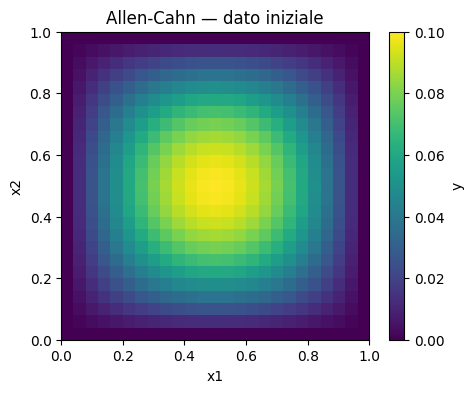

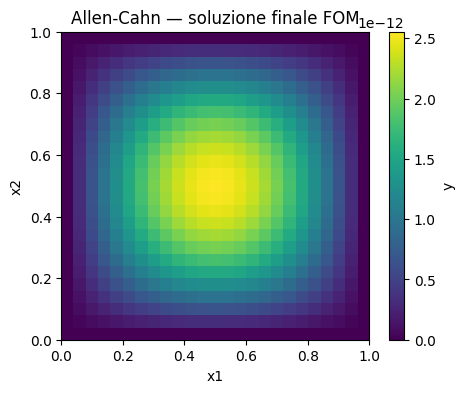

In [24]:
# Soluzione di riferimento richiesta dalla traccia
alpha_ac=0.1
mu_ac=11.0
T_ac=2.0
N_ac=25
dt_ac=0.01

start=time.perf_counter()
xac,tac,Yac,Nac,Lac,dt_eff=allen_cahn_fom(alpha_ac,mu_ac,T_ac,N_ac,dt_ac,snapshot_stride=5)
t_fom_ac=time.perf_counter()-start
print(f'Allen-Cahn FOM completato in {t_fom_ac:.3f} s, snapshots={Yac.shape[1]}')
plot_2d_snapshot(xac,Yac[:,0],'Allen-Cahn — dato iniziale')
plot_2d_snapshot(xac,Yac[:,-1],'Allen-Cahn — soluzione finale FOM')

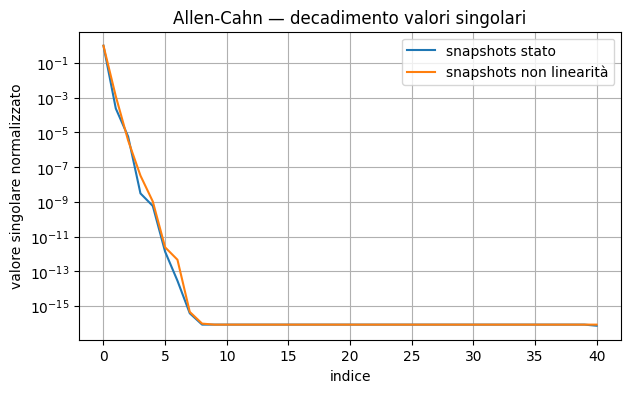

In [25]:
# Basi POD dello stato e della non linearità
Uy,sy,_=pod_basis(Yac)
Uf,sf,_=pod_basis(Nac)

plt.figure(figsize=(7,4))
plt.semilogy(sy/sy[0],label='snapshots stato')
plt.semilogy(sf/sf[0],label='snapshots non linearità')
plt.xlabel('indice'); plt.ylabel('valore singolare normalizzato')
plt.title('Allen-Cahn — decadimento valori singolari')
plt.grid(True); plt.legend(); plt.show()

In [26]:
def allen_cahn_pod(Phi, L, y0, alpha, mu, T, dt,
                   newton_tol=1e-10, newton_maxit=20):
    r=Phi.shape[1]
    Ar=Phi.T@(L@Phi)
    z=Phi.T@y0
    Nt=int(np.ceil(T/dt)); dt=T/Nt
    Y=np.empty((Phi.shape[0],Nt+1)); Y[:,0]=Phi@z

    for k in range(Nt):
        zold=z.copy(); zn=z.copy()
        for _ in range(newton_maxit):
            y=Phi@zn
            nl=mu*(y**3-y)
            G=zn-zold-dt*(alpha*(Ar@zn)+Phi.T@nl)
            D=mu*(3*y**2-1)
            Jr=np.eye(r)-dt*(alpha*Ar + Phi.T@(D[:,None]*Phi))
            dz=solve(Jr,G)
            znew=zn-dz
            if norm(znew-zn)<=newton_tol*(1+norm(znew)):
                zn=znew; break
            zn=znew
        z=zn
        Y[:,k+1]=Phi@z
    return Y


def allen_cahn_pod_deim(Phi, Udeim, p, L, y0, alpha, mu, T, dt,
                         newton_tol=1e-10, newton_maxit=20):
    r=Phi.shape[1]
    m=len(p)
    U=Udeim[:,:m]
    Ar=Phi.T@(L@Phi)

    # Matrici online precomputate
    B=(Phi.T@U) @ np.linalg.inv(U[p,:])   # r x m
    C=Phi[p,:]                            # m x r

    z=Phi.T@y0
    Nt=int(np.ceil(T/dt)); dt=T/Nt
    Y=np.empty((Phi.shape[0],Nt+1)); Y[:,0]=Phi@z

    for k in range(Nt):
        zold=z.copy(); zn=z.copy()
        for _ in range(newton_maxit):
            yp=C@zn
            nlp=mu*(yp**3-yp)
            G=zn-zold-dt*(alpha*(Ar@zn)+B@nlp)

            deriv=mu*(3*yp**2-1)
            Jr=np.eye(r)-dt*(alpha*Ar + B@(deriv[:,None]*C))
            dz=solve(Jr,G)
            znew=zn-dz
            if norm(znew-zn)<=newton_tol*(1+norm(znew)):
                zn=znew; break
            zn=znew
        z=zn
        Y[:,k+1]=Phi@z
    return Y

   r    m      err POD      t POD   err POD-DEIM   t POD-DEIM
   4    8   1.4144e-08     0.0375     1.4144e-08       0.0232
   8    8   3.1609e-13     0.0546     8.4451e-12       0.0252
  12   12   2.4144e-13     0.0420     2.4805e-13       0.0226
Tempo FOM di riferimento: 0.6099 s


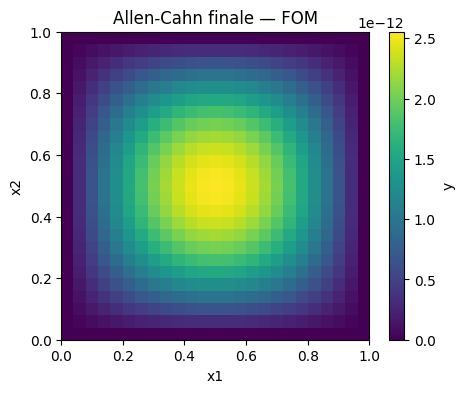

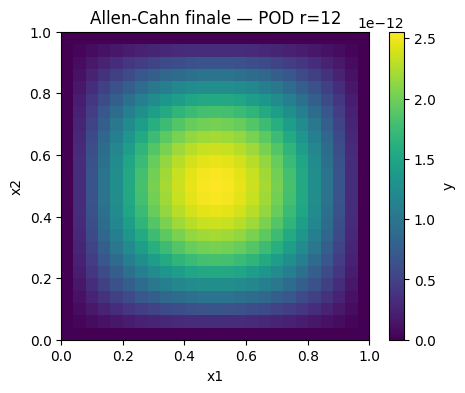

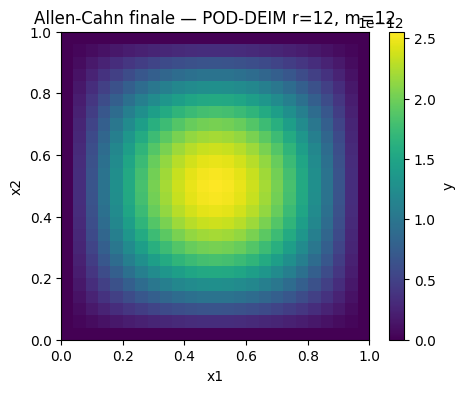

In [27]:
# Confronto errori e tempi POD / POD-DEIM
# Per il confronto con il FOM ci serve una reference sulla griglia temporale fitta.
start=time.perf_counter()
_,_,Yref_ac,_,Lac_fine,_=allen_cahn_fom(alpha_ac,mu_ac,T_ac,N_ac,dt_ac,snapshot_stride=1)
t_ref=time.perf_counter()-start

xi=xac[1:-1]
XX,YY=np.meshgrid(xi,xi,indexing='ij')
y0_ac=(0.1*np.sin(np.pi*XX)*np.sin(np.pi*YY)).reshape(-1)

results=[]
for r in [4,8,12]:
    if r>Uy.shape[1]:
        continue
    Phi=Uy[:,:r]

    start=time.perf_counter()
    Ypod=allen_cahn_pod(Phi,Lac_fine,y0_ac,alpha_ac,mu_ac,T_ac,dt_ac)
    tpod=time.perf_counter()-start
    epod=norm(Yref_ac-Ypod,'fro')/norm(Yref_ac,'fro')

    m=min(max(r,8),Uf.shape[1])
    p=deim_indices(Uf,m)
    start=time.perf_counter()
    Ypd=allen_cahn_pod_deim(Phi,Uf,p,Lac_fine,y0_ac,alpha_ac,mu_ac,T_ac,dt_ac)
    tpd=time.perf_counter()-start
    epd=norm(Yref_ac-Ypd,'fro')/norm(Yref_ac,'fro')

    results.append((r,m,epod,tpod,epd,tpd))

print(f"{'r':>4} {'m':>4} {'err POD':>12} {'t POD':>10} {'err POD-DEIM':>14} {'t POD-DEIM':>12}")
for row in results:
    print(f"{row[0]:4d} {row[1]:4d} {row[2]:12.4e} {row[3]:10.4f} {row[4]:14.4e} {row[5]:12.4f}")
print(f'Tempo FOM di riferimento: {t_ref:.4f} s')

if results:
    r,m,_,_,_,_=results[-1]
    Phi=Uy[:,:r]
    p=deim_indices(Uf,m)
    Ypod=allen_cahn_pod(Phi,Lac_fine,y0_ac,alpha_ac,mu_ac,T_ac,dt_ac)
    Ypd=allen_cahn_pod_deim(Phi,Uf,p,Lac_fine,y0_ac,alpha_ac,mu_ac,T_ac,dt_ac)
    plot_2d_snapshot(xac,Yref_ac[:,-1],'Allen-Cahn finale — FOM')
    plot_2d_snapshot(xac,Ypod[:,-1],f'Allen-Cahn finale — POD r={r}')
    plot_2d_snapshot(xac,Ypd[:,-1],f'Allen-Cahn finale — POD-DEIM r={r}, m={m}')

## Caso parametrico Allen–Cahn

In [29]:
RUN_PARAMETRIC_ALLEN_CAHN = True

if RUN_PARAMETRIC_ALLEN_CAHN:
    alpha_train = [0.03, 0.1, 0.4, 0.9]
    mu_train = [2.0, 5.0, 8.0, 11.0]
    Ybank=[]; Nbank=[]
    Np=21; dtp=0.02; Tp=1.0

    for a in alpha_train:
        for mu in mu_train:
            _,_,Ya,Na,Lp,_=allen_cahn_fom(a,mu,Tp,Np,dtp,snapshot_stride=5)
            Ybank.append(Ya); Nbank.append(Na)

    Ytrain=np.hstack(Ybank)
    Ntrain=np.hstack(Nbank)
    Uypar, sypar, _ = pod_basis(Ytrain)
    Ufpar, sfpar, _ = pod_basis(Ntrain)

    # parametro non visto
    a_test=0.23
    mu_test=7.3
    _,_,Ytest,_,Ltest,_=allen_cahn_fom(a_test,mu_test,Tp,Np,dtp,snapshot_stride=1)

    x=np.linspace(0,1,Np); xi=x[1:-1]
    XX,YY=np.meshgrid(xi,xi,indexing='ij')
    y0=(0.1*np.sin(np.pi*XX)*np.sin(np.pi*YY)).reshape(-1)

    r=10; m=12
    Phi=Uypar[:,:r]
    p=deim_indices(Ufpar,m)
    Ypd=allen_cahn_pod_deim(Phi,Ufpar,p,Ltest,y0,a_test,mu_test,Tp,dtp)
    print('Errore parametrico POD-DEIM:', norm(Ytest-Ypd,'fro')/norm(Ytest,'fro'))

Errore parametrico POD-DEIM: 7.937814594643435e-16
